## Radio interferometría y síntesis de imágenes en astronomía - Laboratorio 2

### Vicente Mieres

In [98]:
%reload_ext autoreload
%autoreload 2

In [99]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# imports
# import numpy as np
# import cupy as cp
from numba import cuda
import math
import matplotlib.pyplot as plt
# modules
from modules.simulation import visibilities_simulation
from modules.optimization import lbfgs_optimize, l1, tsv, entropy
from modules.interferometry import forward_op, adjoint_op, restore_image, get_dirty_image
from modules.plots import plot_uv_coverage, plot, plot_time_vs_grid, plot_speedups
from modules.gridder import get_grid_config, grid_visibilities
from modules.noise import add_gaussian_noise
from modules.utils import benchmark_gridding
from modules.backend import xp


Para efectos de este laboratorio se utilizará una simulación de visibilidades con las siguientes especificaciones:

In [100]:
# simulate visibilities no grid
VLA_L_4 = {
  "latitude": 34.078749,
  "longitude": -107.617728,
  "file_route": "../antenna_arrays/alma.cycle10.8.cfg",
  "catalog_source": "Sirius",
  "utc_start": "2024-10-21T00:00:00",
  "utc_end": "2024-10-21T06:00:00",
  "step_min": 5,
  "n_freqs": 4,
  "interferometer": {
    "name": "VLA",
    "band_name": "L" },
  "n_sources": 100,
  "max_offset_deg": 2,
  "flux_range": [0.1, 2.0],
  "seed": 42
  }

V, uvw, uvw_lambda, frequencies, baselines_enu = visibilities_simulation(VLA_L_4)


## Parte 1: Optimización de gridding con GPU

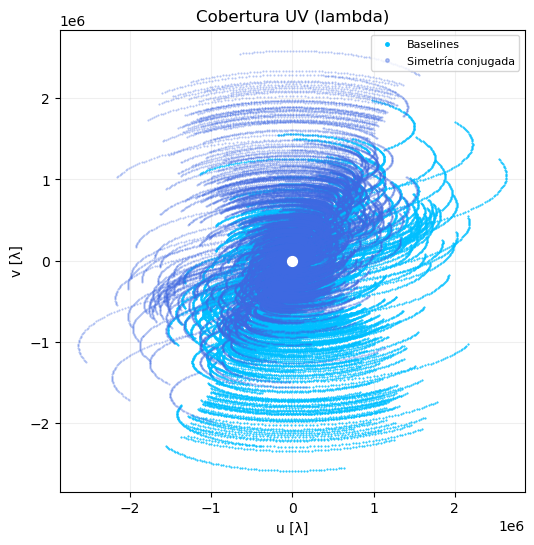

In [101]:
plot_uv_coverage(uvw, unit='lambda')

La función `get_grid_config()` nos entrega todos los elementos necesarios para realizar el gridding de manera correcta

In [102]:
N = 1024
grid_config = get_grid_config(V, uvw_lambda, N, baselines_enu, oversampling_factor=4, frequencies=frequencies, add_noise=True)
grid_config.keys()

Ruido agregado | SNR: 20dB | Sigma: 7.56e-01


dict_keys(['V', 'uvw_lambda', 'du', 'dv', 'Dmax', 'frequencies', 'oversampling_factor', 'baselines', 'Npix', 'pixel_size_image'])

Se implmentó el gridding según lo indicado, es decir la versión numpy (CPU), cupy (gpu) Y numba cuda.

In [103]:
%%time
# CPU - numpy
VG_cpu, WG_cpu = grid_visibilities(grid_config=grid_config, mode='numpy')

Backend a utilizar: numpy
CPU times: user 20.6 ms, sys: 889 μs, total: 21.5 ms
Wall time: 20.7 ms


In [104]:
%%time
# GPU - cupy
VG_gpu, WG_gpu  = grid_visibilities(grid_config=grid_config, mode='cupy')

Backend a utilizar: cupy
CPU times: user 3.26 ms, sys: 5.52 ms, total: 8.78 ms
Wall time: 8.37 ms


In [105]:
%%time
# numba cuda
VG_numba, WG_numba = grid_visibilities(grid_config=grid_config, mode='numba')

Backend a utilizar: numba
CPU times: user 2.55 ms, sys: 19 μs, total: 2.57 ms
Wall time: 2.18 ms


In [106]:
V_ideal = V
V_noisy = add_gaussian_noise(V, 20)

VG_ideal, WG = grid_visibilities(V_ideal, uvw_lambda, grid_config['du'], grid_config['dv'], grid_config['Npix'], mode='numpy')
VG_noisy, WG_N = grid_visibilities(V_noisy, uvw_lambda, grid_config['du'], grid_config['dv'], grid_config['Npix'], mode='numpy')

Ruido agregado | SNR: 20dB | Sigma: 7.56e-01
Backend a utilizar: numpy
Backend a utilizar: numpy


### Agregado de ruido gaussiano

Tal como se indica en el enunciado se incluye ruido gaussiano en las visibilidades, esto se ve a continuación:

Generating plot with scale: 5 (Figure size: 15.0x5.0 inches)


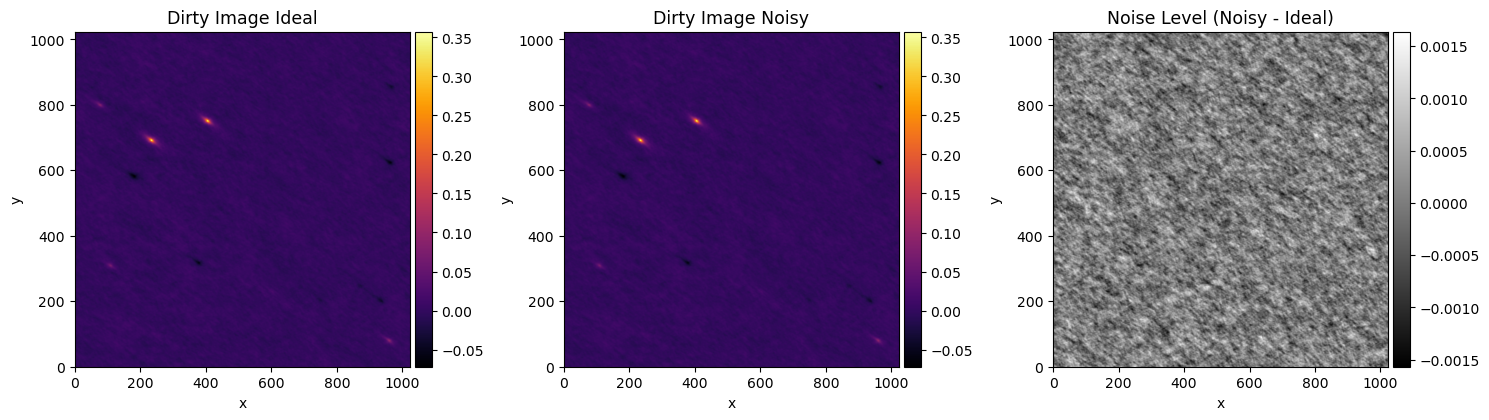

In [107]:
dirty_image_ideal = get_dirty_image(VG_ideal, WG)
dirty_image_noisy = get_dirty_image(VG_noisy,  WG_N)
noise_level = dirty_image_noisy - dirty_image_ideal

images = [
    {'image':dirty_image_ideal, 'title':'Dirty Image Ideal', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':dirty_image_noisy, 'title':'Dirty Image Noisy', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':noise_level, 'title':'Noise Level (Noisy - Ideal)', 'xlabel':'x', 'ylabel':'y', 'cmap': 'gray'}
]

plot(images, (1,3), scale=5)

### Comparación de Rendimiento

Además, se presenta el análisis de comparación de rendimiento entre las diferentes implementaciones de gridding. En esta podemos ver como numba/cuda posee la mayor velocidad en comparación los otros métodos. Si bien cupy no se aleja demasiado, numpy si presenta un rendimiento bastante inferior.

Esta comparacion se realizó para 5 tamaños de grilla diferentes. [256, 512, 1024, 2048, 4096].

Calentando kernels de Numba...
Backend a utilizar: numba
--- Midiendo para N = 256x256 ---
Backend a utilizar: numpy
Backend a utilizar: cupy
Backend a utilizar: numba
   CPU: 0.0160s | CuPy: 0.0020s | Numba: 0.0015s
--- Midiendo para N = 512x512 ---
Backend a utilizar: numpy
Backend a utilizar: cupy
Backend a utilizar: numba
   CPU: 0.0152s | CuPy: 0.0028s | Numba: 0.0017s
--- Midiendo para N = 1024x1024 ---
Backend a utilizar: numpy
Backend a utilizar: cupy
Backend a utilizar: numba
   CPU: 0.0182s | CuPy: 0.0023s | Numba: 0.0018s
--- Midiendo para N = 2048x2048 ---
Backend a utilizar: numpy
Backend a utilizar: cupy
Backend a utilizar: numba
   CPU: 0.0210s | CuPy: 0.0031s | Numba: 0.0024s
--- Midiendo para N = 4096x4096 ---
Backend a utilizar: numpy
Backend a utilizar: cupy
Backend a utilizar: numba
   CPU: 0.0339s | CuPy: 0.0053s | Numba: 0.0037s


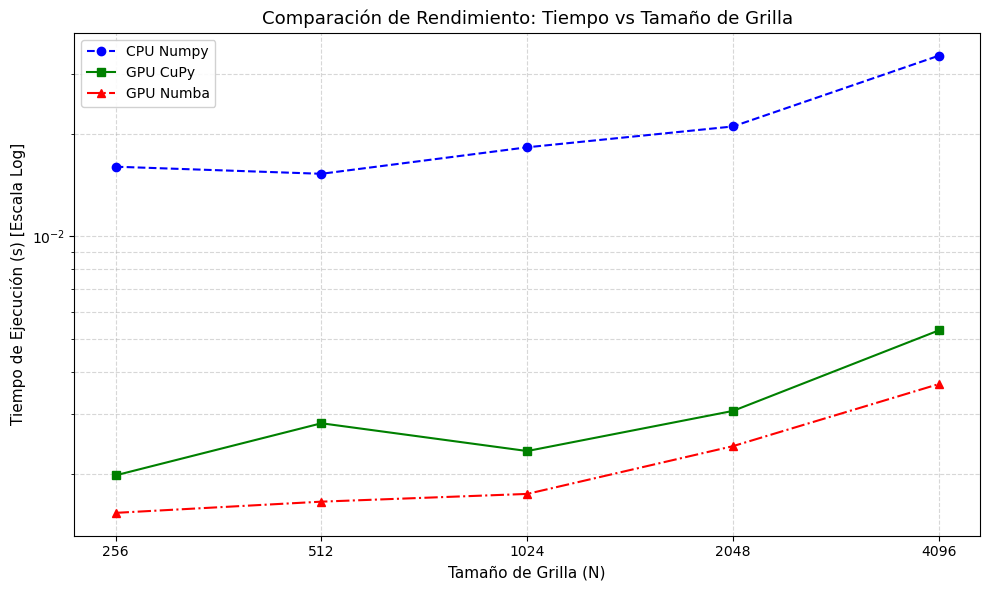

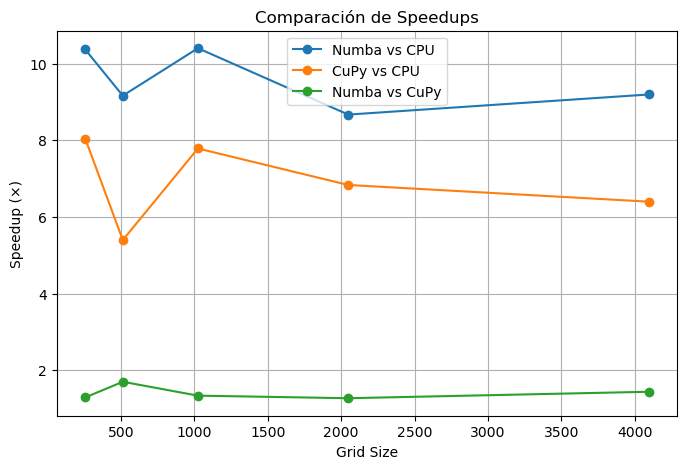

In [124]:
df_results = benchmark_gridding(
    grid_config.get('V'), 
    grid_config.get('uvw_lambda'), 
    grid_config.get('du'), grid_config.get('dv'), 
    grid_sizes=[256, 512, 1024, 2048, 4096])
times = plot_time_vs_grid(df_results)
speedups = plot_speedups(df_results)

## Parte 2: Reconstrucción mediante optimización

Para esta sección del laboratorio se solicitó lo siguiente:
- Operador directo $\mathcal{F}$ y Operado adjunto $\mathcal{F}*$
- La función objetivo y su gradiente
- Términos de regularización R(I)
- Algoritmo de optimización, en este caso LBFGS
- Validación final

Las funciones `forward_op()` y `adjoint_op` describen los procesos a realizar por el operador directo y adjunto respectivamente.
- `forward_op()`: mapea la imagen al espacio de Fourier
- `adjoint_op()`: mapea las visibilidades grideadas de vuelta a la imagen

La función `obj_function()`, realiza el calculo de chi cuadrado ($\mathcal{X}$), su gradiente y además realiza los calculos finales considerando la regularización correspondiente. Es decir, obtiene el argumento de la función objetivo a minimizar:
$$\frac{1}{2}||V - \mathcal{F}(I)||_{w}^{2} + \lambda R(I)$$

`l1()`, `tsv()` y `entropy()` entregan el valor de la función de costo y su gradiente asociado para cada uno de los terminos de regularización Norma L1, Total Squared Variation y Entropía.

Finalmente, `lbfgs_optimize()` realiza la optimización de la función objetivo por medio del algoritmo LBFGS y entrega la imagen reconstruida.


#### Elección de parámetros

La elección de parámetros de cada una de las reconstrucciones se realizó mediante un 'grid search' manual, se probaron diferentes magnitudes y se escogió las que dieran mejores resultados.

El parámetro `lambda_reg` se tomó como un porcentaje del valor máximo de la dirty image (10%). El número de iteraciones se estableció en 100, puesto que un número más elevado no presentó mejoras en los resultados. 

A continuación se realiza la recontrucción de la imagen utilizando todos los tipos de regularizaciones.

In [109]:
# todas las imagenes serán reconstruidas a partir de una imagen en 0 de dimensión (N,N)
Img_init = xp.zeros((N,N))

# Lambda regularization
dirty_image = get_dirty_image(VG_numba, WG_numba)

lambda_reg = 0.1 * xp.max(xp.abs(dirty_image))

print('lambda_reg:',lambda_reg)

lambda_reg: 0.033652205


### Norma L1

In [110]:
args =(VG_numba, WG_numba, lambda_reg, l1)

I_model_l1, info_l1 = lbfgs_optimize(args=args,
                            x0=Img_init,
                            m=10,
                            verbose=True)

[LBFGS] it=0 cost=3.212437e+06 ||g||=6.337e+00
[LBFGS] it=1 cost=2.806943e+06 ||g||=3.601e+01 alpha=3.12e-02
[LBFGS] it=2 cost=2.733805e+06 ||g||=3.385e+01 alpha=5.00e-01
[LBFGS] it=3 cost=2.761511e+06 ||g||=3.340e+01 alpha=1.00e-03
[LBFGS] it=4 cost=2.799857e+06 ||g||=3.322e+01 alpha=1.00e-03
[LBFGS] it=5 cost=2.839898e+06 ||g||=3.371e+01 alpha=1.00e-03
[LBFGS] it=6 cost=2.861155e+06 ||g||=3.376e+01 alpha=1.00e-03
[LBFGS] it=7 cost=2.878872e+06 ||g||=3.410e+01 alpha=1.00e-03
[LBFGS] it=8 cost=2.883949e+06 ||g||=3.405e+01 alpha=1.00e-03
[LBFGS] it=9 cost=2.890246e+06 ||g||=3.425e+01 alpha=1.00e-03
[LBFGS] it=10 cost=2.889502e+06 ||g||=3.415e+01 alpha=1.00e-03
[LBFGS] it=11 cost=2.891981e+06 ||g||=3.428e+01 alpha=1.00e-03
[LBFGS] it=12 cost=2.889790e+06 ||g||=3.419e+01 alpha=1.00e-03
[LBFGS] it=13 cost=2.890750e+06 ||g||=3.427e+01 alpha=1.00e-03
[LBFGS] it=14 cost=2.888681e+06 ||g||=3.420e+01 alpha=1.00e-03
[LBFGS] it=15 cost=2.888981e+06 ||g||=3.427e+01 alpha=1.00e-03
[LBFGS] it=16 cos

In [111]:
I_restored_l1, I_resid_l1, beam_l1 = restore_image(
    I_model=I_model_l1,  # La que salió del LBFGS
    V_obs=VG_numba,               # Visibilidades observadas (Grideadas)
    weights=WG_numba,             # Pesos
    uvw_lambda=xp.asarray(uvw_lambda),         # Coordenadas UVW originales (en GPU)
    pixel_size=grid_config['pixel_size_image'],
    forward_op=forward_op,
    adjoint_op=adjoint_op
)

Generating plot with scale: 5 (Figure size: 10.0x15.0 inches)


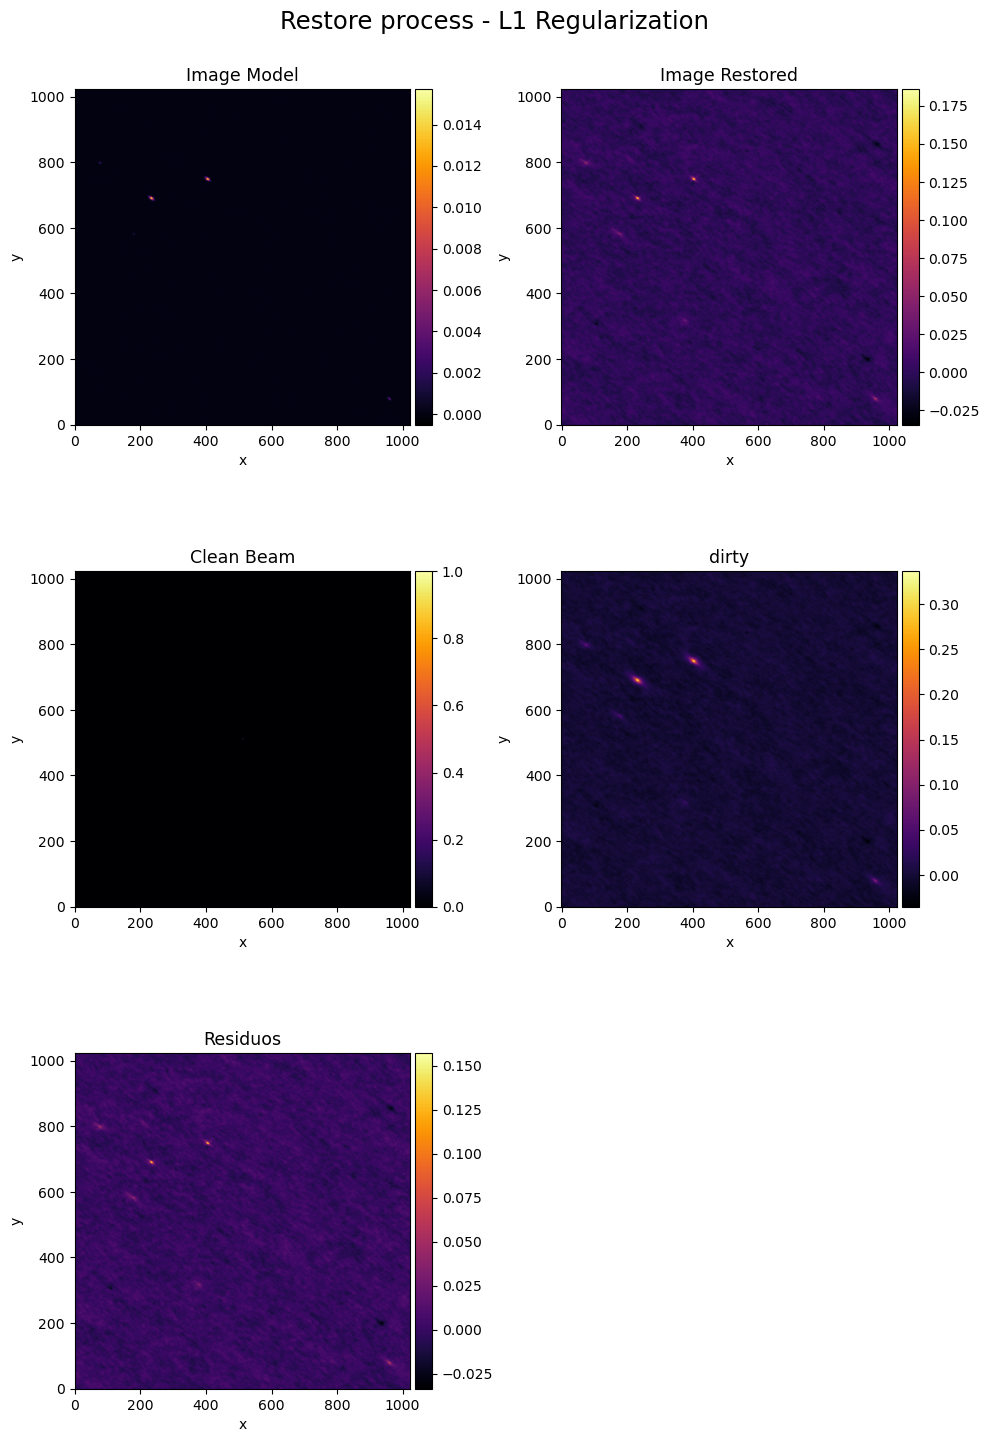

In [ ]:
plot_l1 = [
    {'image':I_model_l1, 'title':'Image Model', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':I_restored_l1.real, 'title':'Image Restored', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':beam_l1, 'title':'Clean Beam', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':dirty_image, 'title':'dirty', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':I_resid_l1, 'title':'Residuos', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
]

plot(fig_title='Restore process - L1 Regularization', data=plot_l1, grid_config=(3,2), scale=5)

### TSV

In [113]:
lambda_reg = 0.1 * xp.max(xp.abs(dirty_image))# lambda_reg =1e-12

print(f'lambda_reg: {lambda_reg}')

lambda_reg: 0.033652205020189285


In [114]:
args =(VG_numba, WG_numba, lambda_reg, tsv)

I_model_tsv, info_tsv = lbfgs_optimize(args=args,
                            x0=Img_init,
                            m=10,
                            verbose=True,
                            armijo_alpha0=0.01,    
                            armijo_rho=0.9,       
                            armijo_c1=1e-4,       
                            armijo_alpha_min=1e-10,
                            armijo_max_iter=30)

I_restored_tsv, I_resid_tsv, beam_tsv = restore_image(
    I_model=I_model_tsv,  # La que salió del LBFGS
    V_obs=VG_numba,               # Visibilidades observadas (Grideadas)
    weights=WG_numba,             # Pesos
    uvw_lambda=xp.asarray(uvw_lambda),         # Coordenadas UVW originales (en GPU)
    pixel_size=grid_config['pixel_size_image'],
    forward_op=forward_op,
    adjoint_op=adjoint_op
)

[LBFGS] it=0 cost=3.212437e+06 ||g||=6.337e+00
[LBFGS] it=1 cost=2.884566e+06 ||g||=4.098e+00 alpha=1.00e-02
[LBFGS] it=2 cost=2.878267e+06 ||g||=4.067e+00 alpha=1.00e-02
[LBFGS] it=3 cost=2.867021e+06 ||g||=4.028e+00 alpha=1.00e-02
[LBFGS] it=4 cost=2.850881e+06 ||g||=3.973e+00 alpha=1.00e-02
[LBFGS] it=5 cost=2.831539e+06 ||g||=3.919e+00 alpha=1.00e-02
[LBFGS] it=6 cost=2.810715e+06 ||g||=3.864e+00 alpha=1.00e-02
[LBFGS] it=7 cost=2.787384e+06 ||g||=3.804e+00 alpha=1.00e-02
[LBFGS] it=8 cost=2.762965e+06 ||g||=3.748e+00 alpha=1.00e-02
[LBFGS] it=9 cost=2.737555e+06 ||g||=3.691e+00 alpha=1.00e-02
[LBFGS] it=10 cost=2.710744e+06 ||g||=3.631e+00 alpha=1.00e-02
[LBFGS] it=11 cost=2.683673e+06 ||g||=3.576e+00 alpha=1.00e-02
[LBFGS] it=12 cost=2.655832e+06 ||g||=3.520e+00 alpha=1.00e-02
[LBFGS] it=13 cost=2.627066e+06 ||g||=3.464e+00 alpha=1.00e-02
[LBFGS] it=14 cost=2.597983e+06 ||g||=3.411e+00 alpha=1.00e-02
[LBFGS] it=15 cost=2.568251e+06 ||g||=3.358e+00 alpha=1.00e-02
[LBFGS] it=16 cos

Generating plot with scale: 5 (Figure size: 10.0x15.0 inches)


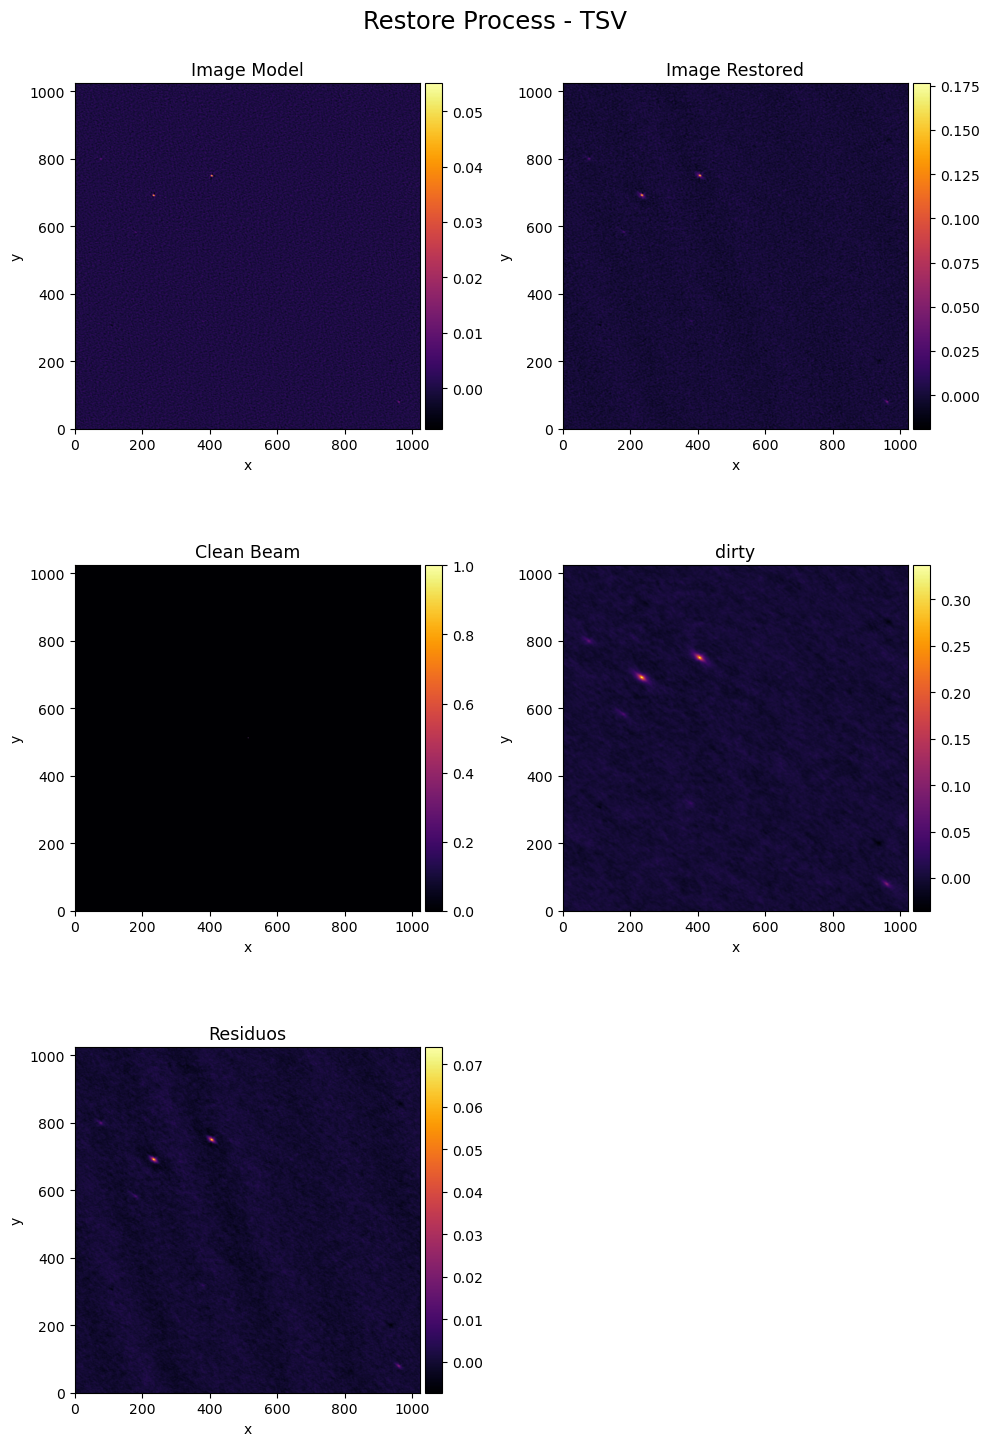

In [115]:
plot_tsv = [
    {'image':I_model_tsv.real, 'title':'Image Model', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':I_restored_tsv.real, 'title':'Image Restored', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':beam_tsv, 'title':'Clean Beam', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':dirty_image, 'title':'dirty', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':I_resid_tsv, 'title':'Residuos', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
]

plot(fig_title='Restore Process - TSV', data=plot_tsv, grid_config=(3,2), scale=5)

### Entropy

In [116]:
lambda_reg = 0.1 * xp.max(xp.abs(dirty_image))

print(f'lambda_reg: {lambda_reg}')

lambda_reg: 0.033652205020189285


In [117]:
args =(VG_numba, WG_numba, lambda_reg, entropy)

I_model_entropy, info_entropy = lbfgs_optimize(
    x0=Img_init,
    args=args,
    m=10,
    verbose=True,
    armijo_alpha0=0.5,    # paso inicial
    armijo_rho=0.7,    # contracción
    armijo_c1=1e-4,       # condición Armijo
    armijo_alpha_min=1e-10,
    armijo_max_iter=30
)

I_restored_entropy, I_resid_entropy, beam_entropy = restore_image(
    I_model=I_model_entropy,  # La que salió del LBFGS
    V_obs=VG_numba,               # Visibilidades observadas (Grideadas)
    weights=WG_numba,             # Pesos
    uvw_lambda=xp.asarray(uvw_lambda),         # Coordenadas UVW originales (en GPU)
    pixel_size=grid_config['pixel_size_image'],
    forward_op=forward_op,
    adjoint_op=adjoint_op
)

[LBFGS] it=0 cost=3.212437e+06 ||g||=9.521e+02
[LBFGS] it=1 cost=9.405361e+06 ||g||=2.282e+02 alpha=1.00e-03
[LBFGS] it=2 cost=1.269763e+07 ||g||=2.178e+02 alpha=1.00e-03
[LBFGS] it=3 cost=1.650390e+07 ||g||=2.092e+02 alpha=1.00e-03
[LBFGS] it=4 cost=2.076851e+07 ||g||=2.016e+02 alpha=1.00e-03
[LBFGS] it=5 cost=2.544516e+07 ||g||=1.949e+02 alpha=1.00e-03
[LBFGS] it=6 cost=3.049420e+07 ||g||=1.889e+02 alpha=1.00e-03
[LBFGS] it=7 cost=3.588098e+07 ||g||=1.833e+02 alpha=1.00e-03
[LBFGS] it=8 cost=4.157474e+07 ||g||=1.782e+02 alpha=1.00e-03
[LBFGS] it=9 cost=4.754793e+07 ||g||=1.734e+02 alpha=1.00e-03
[LBFGS] it=10 cost=5.377564e+07 ||g||=1.688e+02 alpha=1.00e-03
[LBFGS] it=11 cost=6.023518e+07 ||g||=1.646e+02 alpha=1.00e-03
[LBFGS] it=12 cost=6.690580e+07 ||g||=1.605e+02 alpha=1.00e-03
[LBFGS] it=13 cost=7.376842e+07 ||g||=1.567e+02 alpha=1.00e-03
[LBFGS] it=14 cost=8.080544e+07 ||g||=1.530e+02 alpha=1.00e-03
[LBFGS] it=15 cost=8.800056e+07 ||g||=1.495e+02 alpha=1.00e-03
[LBFGS] it=16 cos

Generating plot with scale: 5 (Figure size: 10.0x15.0 inches)


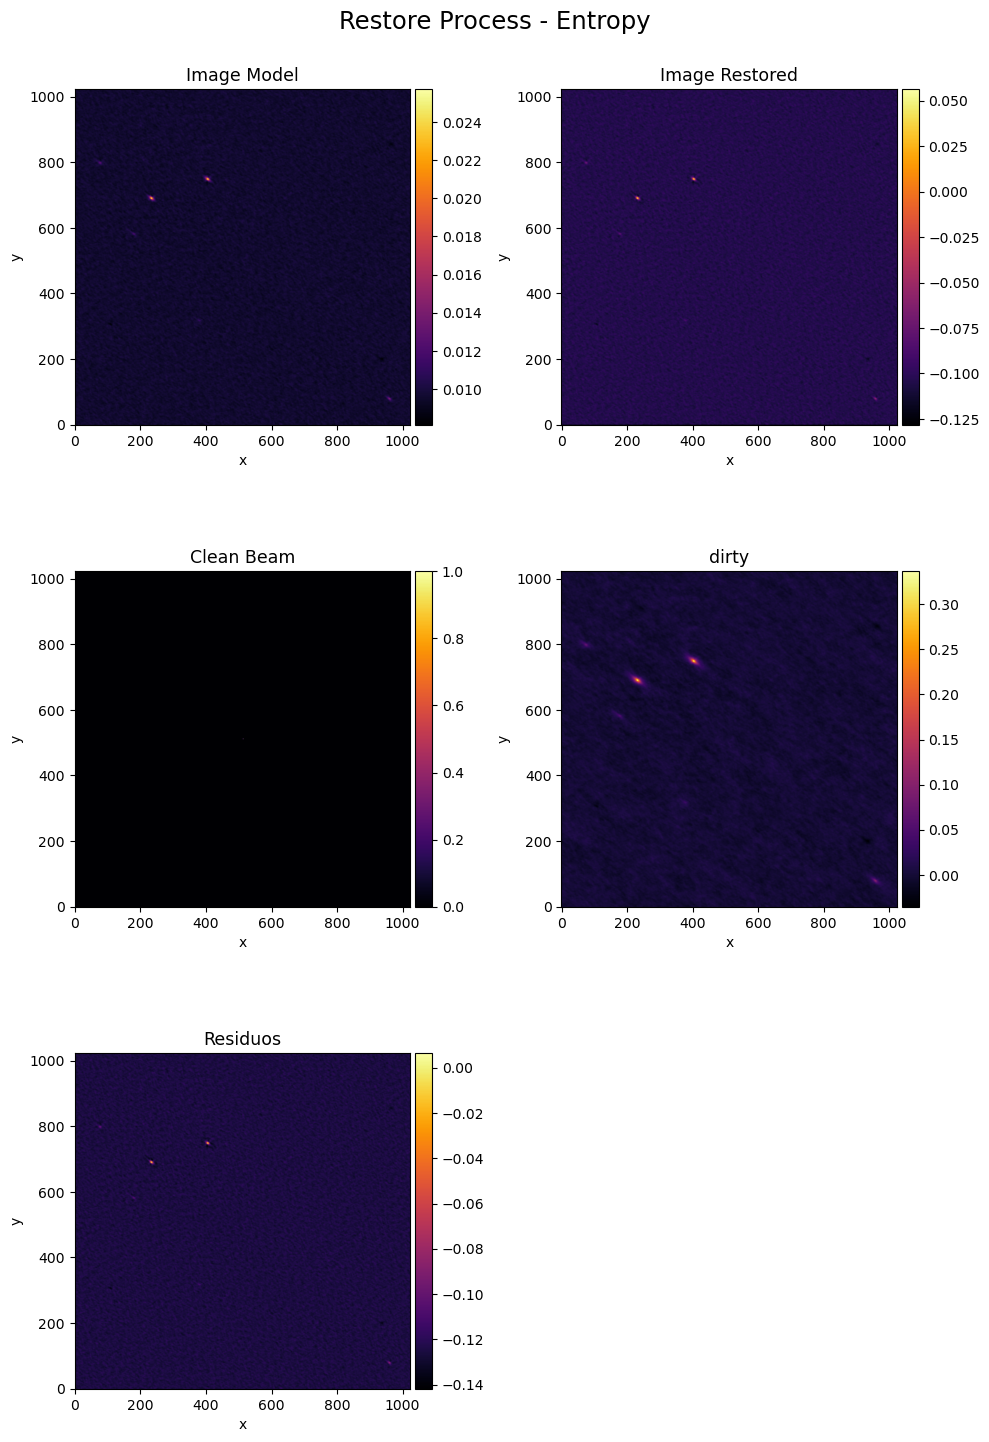

In [118]:
plot_entropy = [
    {'image':I_model_entropy.real, 'title':'Image Model', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':I_restored_entropy.real, 'title':'Image Restored', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':beam_entropy, 'title':'Clean Beam', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':dirty_image, 'title':'dirty', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
    {'image':I_resid_entropy, 'title':'Residuos', 'xlabel':'x', 'ylabel':'y', 'cmap': 'inferno'},
]

plot(fig_title='Restore Process - Entropy', data=plot_entropy, grid_config=(3,2), scale=5)

### Validación

Con el fin de validar y/o estudiar la calidad de la reconstrucción realizada, se implementaron 2 métricas, estas son:

- `PSNR`: Mide la calidad de la reconstrucción. Un valor alto indica menor error.
- `MAD STD`: Nivel de ruido residual. A menor valor, mejor resultado.




In [119]:
from modules.utils import calculate_quality_metrics

# Calcular métricas
mad_std_val_l1, psnr_val_l1 = calculate_quality_metrics(I_restored_l1, I_resid_l1)
mad_std_val_tsv, psnr_val_tsv = calculate_quality_metrics(I_restored_tsv, I_resid_tsv)
mad_std_val_entropy, psnr_val_entropy = calculate_quality_metrics(I_restored_entropy, I_resid_entropy)


print(f"--- Métricas de Calidad de Imagen -Regularización L1 ---")
print(f"MAD STD (Nivel de Ruido Estimado): {mad_std_val_l1:.6f}")
print(f"PSNR (Rango Dinámico - Lineal):    {psnr_val_l1:.2f}")
# Opcional: Calcular PSNR en Decibeles (dB)
psnr_db_l1 = 20 * xp.log10(float(psnr_val_l1))
print(f"PSNR (Escala Logarítmica):         {psnr_db_l1:.2f} dB")

print('\n')

print(f"--- Métricas de Calidad de Imagen -Regularización TSV ---")
print(f"MAD STD (Nivel de Ruido Estimado): {mad_std_val_tsv:.6f}")
print(f"PSNR (Rango Dinámico - Lineal):    {psnr_val_tsv:.2f}")

# Opcional: Calcular PSNR en Decibeles (dB)
psnr_db_tsv = 20 * xp.log10(float(psnr_val_tsv))
print(f"PSNR (Escala Logarítmica):         {psnr_db_tsv:.2f} dB")

print('\n')

print(f"--- Métricas de Calidad de Imagen -Regularización Entropy ---")
print(f"MAD STD (Nivel de Ruido Estimado): {mad_std_val_entropy:.6f}")
print(f"PSNR (Rango Dinámico - Lineal):    {psnr_val_entropy:.2f}")

# Opcional: Calcular PSNR en Decibeles (dB)
psnr_db_entropy = 20 * xp.log10(float(psnr_val_entropy))
print(f"PSNR (Escala Logarítmica):         {psnr_db_entropy:.2f} dB")

--- Métricas de Calidad de Imagen -Regularización L1 ---
MAD STD (Nivel de Ruido Estimado): 0.004007
PSNR (Rango Dinámico - Lineal):    46.41
PSNR (Escala Logarítmica):         33.33 dB


--- Métricas de Calidad de Imagen -Regularización TSV ---
MAD STD (Nivel de Ruido Estimado): 0.001090
PSNR (Rango Dinámico - Lineal):    161.73
PSNR (Escala Logarítmica):         44.18 dB


--- Métricas de Calidad de Imagen -Regularización Entropy ---
MAD STD (Nivel de Ruido Estimado): 0.001922
PSNR (Rango Dinámico - Lineal):    29.31
PSNR (Escala Logarítmica):         29.34 dB


A partir de esto la regularización TSV demostró ser la opción óptima, logrando la máxima fidelidad (PSNR 44.04 dB) y el menor ruido residual (MAD 0.0011). Por el contrario, L1 presentó un ajuste deficiente con el triple de ruido residual debido a la generación de artefactos de pixelado , mientras que Entropía obtuvo el peor rendimiento (PSNR 29.31 dB) al atenuar excesivamente el brillo de la señal restaurada.

Además, se estudió la convergencia del algortimo según la regularización utilizada. En estos se puede ver nuevamente que TSV supera a L1 y Entropy, a tal punto que entropy no converge, sino diverge.

In [ ]:
plot_convergence = [
    {
        'image': xp.array(info_l1["cost_history"]),
        'title': 'Convergencia - L1',
        'xlabel': 'Iteración',
        'ylabel': 'Costo',
    },
    {
        'image': xp.array(info_tsv["cost_history"]),
        'title': 'Convergencia - TSV',
        'xlabel': 'Iteración',
        'ylabel': 'Costo',
    },
    {
        'image': xp.array(info_entropy["cost_history"]),
        'title': 'Convergencia - Entropía',
        'xlabel': 'Iteración',
        'ylabel': 'Costo',
    }
]

plot(
    data=plot_convergence,
    grid_config=(1,3),
    scale=4,
    fig_title="Convergencia de los métodos"
)


Finalmente se presentan los tiempos asociados.

In [122]:
print(f'Tiempo L1 {info_l1['time']}[s]\n')
print(f'Tiempo TSV {info_tsv['time']}[s]\n')
print(f'Tiempo Entropy {info_entropy['time']}[s]')

Tiempo L1 7.2294652462005615[s]

Tiempo TSV 1.2679848670959473[s]

Tiempo Entropy 9.670026540756226[s]
